# Hall of Monitors: Computational Explorations

**Flyxion — August 2026**

This notebook turns several ideas from *Hall of Monitors* into synthetic computational experiments. It is not empirical validation; the simulations make the formal distinctions manipulable.

The shared state is $S(t)$, with participant-specific projections

$$
M_j(t) = \Pi_j\!\left(S(t)\right).
$$

We explore selective projection, coordination equivalence and aliasing, noise floors, the distinction

$$
G_{\mathrm{produce}} \neq G_{\mathrm{perceive}},
$$

iterative personalization, indexed recoverability, and minimal coordination messages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (10, 5)

## 1. One Shared Performance, Several Legitimate Mixes

A four-component performance supplies $S(t)$. Each participant receives a deliberately unequal linear projection. The experiment illustrates why

$$
M_i = M_j
$$

is not the coordination criterion.

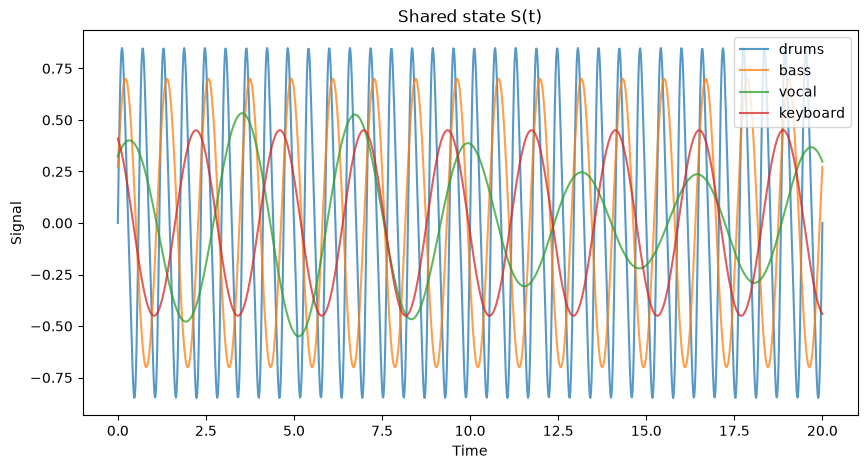

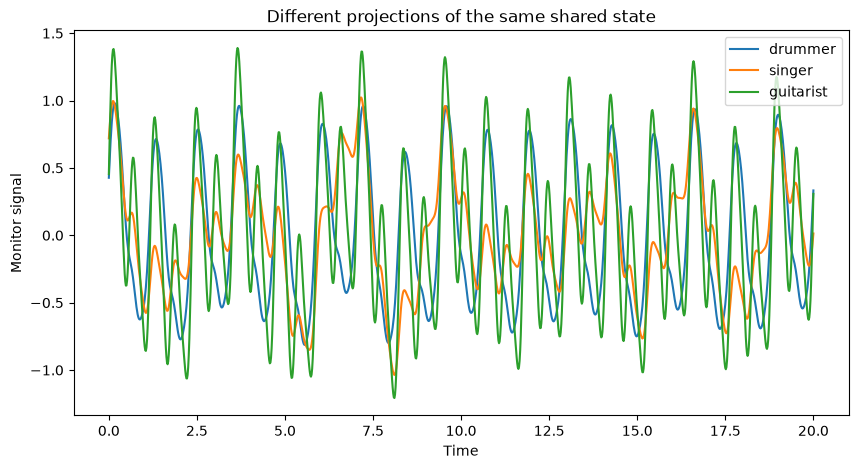

In [2]:
t = np.linspace(0, 20, 1200)
S = pd.DataFrame({
    "drums": 0.8*np.sin(2*np.pi*1.7*t) + 0.15*np.sin(2*np.pi*3.4*t),
    "bass": 0.7*np.sin(2*np.pi*0.85*t + 0.4),
    "vocal": 0.55*np.sin(2*np.pi*0.31*t + 1.0)*(0.7+0.3*np.sin(2*np.pi*0.05*t)),
    "keyboard": 0.45*np.sin(2*np.pi*0.42*t + 2.0)}, index=t)
weights = pd.DataFrame({
    "drummer":[0.20,1.00,0.35,0.10],
    "singer":[0.25,0.25,1.00,0.80],
    "guitarist":[0.85,0.55,0.75,0.15]}, index=S.columns)
M={p:S.to_numpy()@weights[p].to_numpy() for p in weights.columns}
ax=S.plot(alpha=.75,title="Shared state S(t)")
ax.set(xlabel="Time",ylabel="Signal"); plt.show()
fig,ax=plt.subplots()
for p,y in M.items(): ax.plot(t,y,label=p)
ax.set(title="Different projections of the same shared state",xlabel="Time",ylabel="Monitor signal")
ax.legend(); plt.show()

## 2. Coordination Equivalence and Projection Aliasing

A projection is dangerous not because it is lossy, but because it can collapse states that require different continuations:

$$
S_a \not\sim_{\mathrm{coord}} S_b,
\qquad
\Pi_j(S_a) = \Pi_j(S_b).
$$

This is cross-class aliasing rather than ordinary compression.

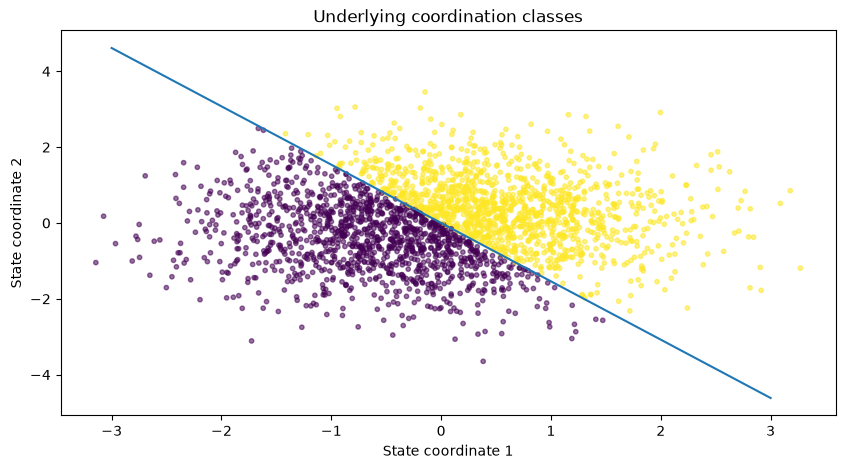

coordination-aligned   approximate aliasing rate: 0.076
partially aligned      approximate aliasing rate: 0.878
poor projection        approximate aliasing rate: 1.000


In [3]:
n=2500
states=rng.normal(size=(n,2))
coord=(states[:,0]+0.65*states[:,1]>0).astype(int)
projections={
 "coordination-aligned":states[:,0]+0.65*states[:,1],
 "partially aligned":states[:,0],
 "poor projection":states[:,0]-1.2*states[:,1]}
fig,ax=plt.subplots()
ax.scatter(states[:,0],states[:,1],c=coord,s=10,alpha=.55)
x=np.linspace(-3,3,100); ax.plot(x,-x/.65)
ax.set(title="Underlying coordination classes",xlabel="State coordinate 1",ylabel="State coordinate 2")
plt.show()

def ambiguity_rate(v,c,bins=35):
    edges=np.linspace(v.min(),v.max(),bins+1)
    b=np.clip(np.digitize(v,edges)-1,0,bins-1)
    ambiguous=np.zeros(len(v),dtype=bool)
    for k in range(bins):
        ix=b==k
        if ix.any() and len(np.unique(c[ix]))>1: ambiguous[ix]=True
    return ambiguous.mean()

for name,p in projections.items():
    print(f"{name:22s} approximate aliasing rate: {ambiguity_rate(p,coord):.3f}")

### 2b. A Tolerance-Swept Aliasing Functional

The bin-collision estimate above is a coarse proxy. The more direct object is a pairwise, tolerance-indexed rate:

$$
\mathcal{A}_{\epsilon}(\Pi)
=
\Pr\!\left[
d_M\!\left(\Pi(S_a),\Pi(S_b)\right)<\epsilon
\;\middle|\;
S_a\not\sim_{\mathrm{coord}}S_b
\right].
$$

This traces a curve rather than a single number, showing how quickly a projection starts confusing consequential distinctions as tolerance loosens.

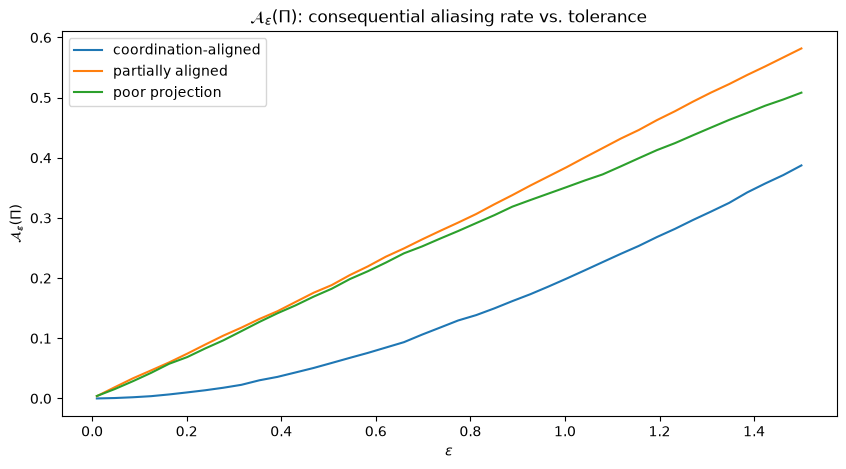

In [5]:
idx_a = rng.integers(0, n, 20000)
idx_b = rng.integers(0, n, 20000)

diff_class = coord[idx_a] != coord[idx_b]
epsilons = np.linspace(0.01, 1.5, 40)

fig, ax = plt.subplots()

for name, proj in projections.items():
    d = np.abs(proj[idx_a] - proj[idx_b])
    rates = [
        np.mean(d[diff_class] < eps)
        for eps in epsilons
    ]
    ax.plot(epsilons, rates, label=name)

ax.set(
    title=r"$\mathcal{A}_\epsilon(\Pi)$: consequential aliasing rate vs. tolerance",
    xlabel=r"$\epsilon$",
    ylabel=r"$\mathcal{A}_\epsilon(\Pi)$",
)

ax.legend()
plt.show()

## 3. Noise Floors and Dynamic Perception Scheduling

Existence, transmission, detectability, and recoverability are different. A dynamic monitor can raise a needed cue above a participant's local noise floor $N_j$ only when it matters.

In [ ]:
t2=np.linspace(0,30,1000)
cue=.18+.05*np.sin(t2*1.3); noise_floor=.35
need=np.exp(-.5*((t2-15)/1.8)**2)
routed=cue*(1+3.2*need)
fig,ax=plt.subplots()
ax.plot(t2,cue,label="cue in shared state")
ax.plot(t2,routed,label="dynamically routed cue")
ax.axhline(noise_floor,linestyle="--",label="participant noise floor")
ax.set(title="Perception routing as threshold manipulation",xlabel="Time",ylabel="Detectability proxy")
ax.legend(); plt.show()
print("Detectable without routing:",round(np.mean(cue>noise_floor),3))
print("Detectable during need window after routing:",round(np.mean(routed[need>.5]>noise_floor),3))

## 4. Production and Perception Are Different Graphs

The production matrix assigns who realizes each component. The perception matrix describes what each participant needs made salient. Their disagreement is not a defect:

$$
G_{\mathrm{produce}}
\neq
G_{\mathrm{perceive}}.
$$

In [ ]:
people=["drummer","bassist","singer","keyboardist"]
components=["drums","bass","vocal","keyboard"]
Gp=pd.DataFrame(np.eye(4),index=people,columns=components)
Gq=pd.DataFrame([[.20,1,.45,.10],[.90,.20,.35,.20],[.25,.30,1,.90],[.65,.45,.80,.25]],
                index=people,columns=components)
display(Gp); display(Gq)
fig,ax=plt.subplots()
im=ax.imshow(Gq.to_numpy(),aspect="auto")
ax.set_xticks(range(4),components); ax.set_yticks(range(4),people)
ax.set_title("G_perceive: what each participant needs made salient")
fig.colorbar(im,ax=ax,label="Perceptual usefulness"); plt.show()
print("Graph difference:",round(np.linalg.norm(Gp.to_numpy()-Gq.to_numpy()),3))

## 5. Hall of Monitors Versus Hall of Mirrors

Repeated personalization can emphasize whatever is already salient. Each step looks locally reasonable while the sequence

$$
S
\;\longrightarrow\;
M_j
\;\longrightarrow\;
M'_j
\;\longrightarrow\;
M''_j
\;\longrightarrow\;
\cdots
$$

progressively concentrates the representation.

Shannon entropy here is only a concentration diagnostic, not a definition of recoverability.

In [ ]:
def personalize(v,strength=1.35,floor=.04):
    out=v*(np.abs(v)+floor)**(strength-1)
    return out/np.linalg.norm(out)
initial=np.array([.58,.50,.42,.36,.30,.25])
traj=[initial/np.linalg.norm(initial)]
for _ in range(14): traj.append(personalize(traj[-1]))
T=np.vstack(traj)
entropy=[]
for row in np.abs(T):
    p=row/row.sum(); entropy.append(-(p*np.log2(p+1e-12)).sum())
fig,ax=plt.subplots()
for k in range(T.shape[1]): ax.plot(range(len(T)),np.abs(T[:,k]),label=f"component {k+1}")
ax.set(title="Iterated personalization concentrates the projection",xlabel="Projection generation",ylabel="Relative salience")
ax.legend(ncol=2); plt.show()
fig,ax=plt.subplots()
ax.plot(range(len(entropy)),entropy,marker="o")
ax.set(title="Representational diversity across successive projections",xlabel="Projection generation",ylabel="Shannon entropy of salience")
plt.show()

### 5b. Analytic Verification of the Concentration Dynamics

The personalization step is

$$
v_i'
=
v_i\left(|v_i|+\varepsilon\right)^{0.35}
\propto
\operatorname{sgn}(v_i)|v_i|^{1.35},
$$

so with $\varepsilon=0$ and probability-style normalization, iterating gives a closed form:

$$
p_i^{(t+1)}
=
\frac{\left(p_i^{(t)}\right)^\gamma}
{\sum_k \left(p_k^{(t)}\right)^\gamma},
\qquad
\gamma=1.35.
$$

After $n$ iterations,

$$
p_i^{(n)}
=
\frac{\left(p_i^{(0)}\right)^{\gamma^n}}
{\sum_k \left(p_k^{(0)}\right)^{\gamma^n}}.
$$

This is checked directly against the simulated trajectory below, both with the floor term present, where a small residual is expected, and with the floor term removed, where the analytic and simulated trajectories should agree to machine precision.

In [ ]:
gamma = 1.35p0 = np.abs(T[0]); p0 = p0/p0.sum()analytic = []for n_ in range(len(T)):    powed = p0**(gamma**n_)    analytic.append(powed/powed.sum())analytic = np.vstack(analytic)sim_probs = np.abs(T)/np.abs(T).sum(axis=1, keepdims=True)print("Max deviation, simulation (with floor) vs analytic formula:", round(np.max(np.abs(sim_probs-analytic)), 4))def personalize_nofloor(v, strength=1.35):    out = v*(np.abs(v))**(strength-1)    return out/np.linalg.norm(out)traj2 = [initial/np.linalg.norm(initial)]for _ in range(14): traj2.append(personalize_nofloor(traj2[-1]))T2 = np.vstack(traj2)sim_probs2 = np.abs(T2)/np.abs(T2).sum(axis=1, keepdims=True)print("Max deviation, simulation (floor removed) vs analytic formula:", np.max(np.abs(sim_probs2-analytic)))print("(Confirms the concentration is exact power-law sharpening, not an artifact of the floor term.)")

## 6. Retained Is Not Recoverable

The system can retain $S$ while the participant receives a projection missing a coordination-relevant coordinate. Thus, system recoverability does not imply participant recoverability:

$$
M_j
\rightsquigarrow_{\mathrm{sys}}
[S]_{\mathrm{coord}}
\;\not\Rightarrow\;
M_j
\rightsquigarrow_j
[S]_{\mathrm{coord}}.
$$

In [ ]:
n=3000
Sf=rng.normal(size=(n,3))
action=((Sf[:,0]+.9*Sf[:,2])>0).astype(int)
participant=Sf[:,:2]

def centroid_accuracy(X,y):
    C=np.vstack([X[y==c].mean(axis=0) for c in [0,1]])
    pred=((X[:,None,:]-C[None,:,:])**2).sum(axis=2).argmin(axis=1)
    return np.mean(pred==y)

print("Recoverability from retained system state:",round(centroid_accuracy(Sf,action),3))
print("Recoverability from participant projection:",round(centroid_accuracy(participant,action),3))

## 7. Minimal Coordination Messages

Private agents need not synchronize complete internal states. If coordination depends only on an action-relevant quotient, a small message can preserve the conclusion without exporting the entire private history:

$$
H_i
\;\longrightarrow\;
[x]_{\mathrm{coord}}
\;\longrightarrow\;
H_j.
$$

In [6]:
d=10; samples=rng.normal(size=(5000,d))
message=(samples[:,0]+samples[:,3]-.7*samples[:,7]>0).astype(int)
full=samples.size; minimal=message.size
print(f"Full-state payload:   {full:,} scalar values")
print(f"Coordination payload: {minimal:,} scalar values")
print(f"Payload reduction:    {1-minimal/full:.1%}")

Full-state payload:   50,000 scalar values
Coordination payload: 5,000 scalar values
Payload reduction:    90.0%


In [7]:
print("\n--- Frontier: candidate messages of varying informativeness ---")


--- Frontier: candidate messages of varying informativeness ---


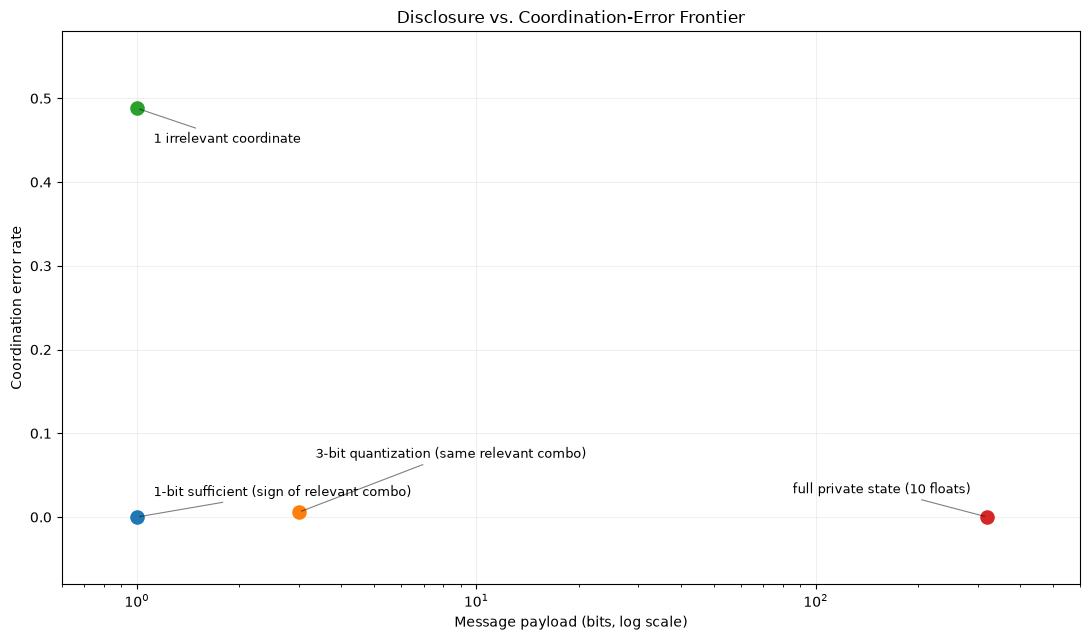

In [10]:
fig, ax = plt.subplots(figsize=(11, 6.5))

# Hand-tuned label positions so the four annotations do not collide.
label_offsets = {
    "1-bit sufficient (sign of relevant combo)": (12, 18),
    "3-bit quantization (same relevant combo)": (12, 42),
    "1 irrelevant coordinate": (12, -22),
    "full private state (10 floats)": (-12, 20),
}

for name, bits, err in frontier:
    ax.scatter(bits, err, s=90, zorder=3)

    dx, dy = label_offsets[name]

    ax.annotate(
        name,
        (bits, err),
        xytext=(dx, dy),
        textcoords="offset points",
        ha="right" if dx < 0 else "left",
        va="center",
        fontsize=9,
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.8,
            alpha=0.5,
        ),
    )

ax.set_xscale("log")

# Explicit limits keep points away from the frame.
ax.set_xlim(0.6, 600)
ax.set_ylim(-0.08, 0.58)

ax.set(
    title="Disclosure vs. Coordination-Error Frontier",
    xlabel="Message payload (bits, log scale)",
    ylabel="Coordination error rate",
)

ax.grid(True, alpha=0.2)
fig.tight_layout()

plt.show()

## Toward an Experimental Theory of Selective Ignorance

The notebook's sections trace a single pipeline rather than eight unrelated demonstrations:

$$
\boxed{
\text{projection}
\;\longrightarrow\;
\text{equivalence classes}
\;\longrightarrow\;
\text{consequential aliasing}
\;\longrightarrow\;
\text{recoverability}
\;\longrightarrow\;
\text{minimal sufficient coordination}
}
$$

Each stage is now backed by at least one runnable estimate rather than only a formal definition. Aliasing has both a coarse bin-collision proxy and a tolerance-swept functional

$$
\mathcal{A}_{\epsilon}(\Pi).
$$

The hall-of-mirrors concentration dynamic has both a simulation and an exact closed form, and minimal sufficient coordination now has a real, if small, disclosure-error frontier rather than a single payload-size comparison.

None of this validates the essay empirically—the data throughout are synthetic. What it does is make the essay's distinctions into objects that can be computed with, disagreed with, and extended.